In [2]:
from hnn_core import jones_2009_model, simulate_dipole
from hnn_core.network_models import add_erp_drives_to_jones_model
from hnn_core.extracellular import calculate_csd2d, _get_laminar_z_coords

import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
from scipy.interpolate import RectBivariateSpline

--No graphics will be displayed.


In [3]:
def plot_full_csd(csd_data, times, layer_boundaries, vmin=-60, vmax=60, title='Laminar CSD', xmin=None, xmax=None):
        plt.figure(figsize=(7,5))
        plt.imshow(csd_data, aspect='auto', cmap='jet_r',
                extent=[times[0], times[-1], 0, csd_data.shape[0]],
                vmin=vmin, vmax=vmax)
        plt.colorbar()
        plt.xlim(xmin, xmax)
        plt.axvline(0, color='w')

        # layer_boundaries_exp = num_contacts_exp - np.array([l2_indices_exp[0], l2_indices_exp[-1], l5_indices_exp[0], l5_indices_exp[-1]])
        plt.hlines(xmin=xmin, xmax=xmax, y=layer_boundaries, color='k', linestyle='--')
        plt.xlabel('Time (ms)')
        plt.ylabel('Contact No.')

        plt.title(title)


def plot_csd_layers(l2_data, l5_data, times, vmin=-60, vmax=60, xmin=None, xmax=None):
        plt.figure(figsize=(7,5))
        plt.subplot(2,1,1)
        plt.imshow(l2_data, aspect='auto', cmap='jet_r',
                        extent=[times[0], times[-1], 0, l2_data.shape[0]],
                        vmin=vmin, vmax=vmax)

        plt.xlim(xmin, xmax)
        plt.axvline(0, color='w', linestyle='-')
        plt.ylabel('Contact No.')
        plt.title('Layer 2/3 CSD')
        plt.colorbar()

        plt.subplot(2,1,2)
        plt.imshow(l5_data, aspect='auto', cmap='jet_r',
                extent=[times[0], times[-1], 0, l5_data.shape[0]],
                vmin=vmin, vmax=vmax)
        plt.xlim(xmin, xmax)
        plt.axvline(0, color='w', linestyle='-')
        plt.xlabel('Time (ms)')
        plt.ylabel('Contact No.')
        plt.title('Layer 5 CSD')
        plt.colorbar()
        plt.tight_layout()

### Prepare empirical CSD data

In [4]:
# Path to your .mat file
file_path = "../data/2-pb3738015_CSD.mat"

# Load the .mat file
# Median nerve stimulation
csd_data_exp = loadmat(file_path)['CSD_traces']
num_contacts_exp = csd_data_exp.shape[0]
times_exp = np.linspace(-50, 450, csd_data_exp.shape[1])

# "More generally, traces 5–9 fall in L2/3, and traces 15–18 fall in L5." - Anna C.
l2_indices_exp = np.array(list(range(3, 10)))
l5_indices_exp = np.array(list(range(13, 18)))
layer_boundaries_exp = num_contacts_exp - np.array([l2_indices_exp[0], l2_indices_exp[-1], l5_indices_exp[0], l5_indices_exp[-1]])

# Extract layer 2/3 and layer 5 data
l2_data_exp = csd_data_exp[l2_indices_exp, :]
l5_data_exp = csd_data_exp[l5_indices_exp, :]


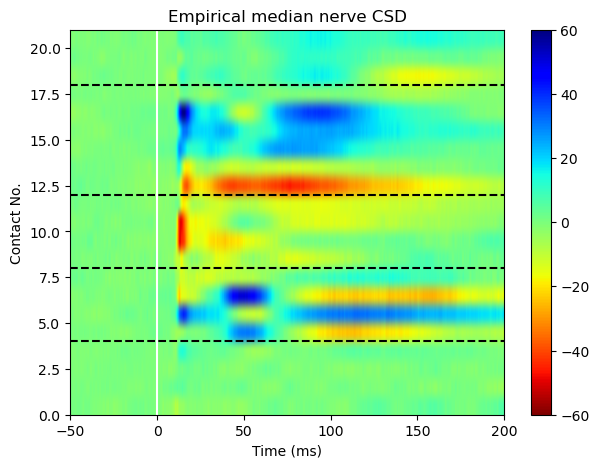

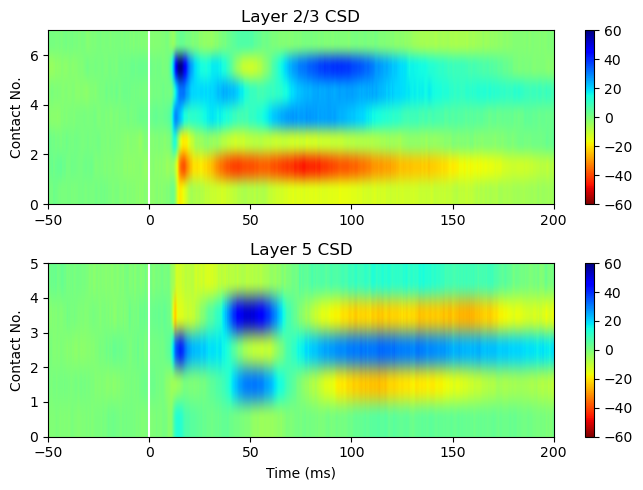

In [5]:
plot_full_csd(csd_data_exp, times_exp, layer_boundaries_exp, xmin=-50, xmax=200, title='Empirical median nerve CSD')
plot_csd_layers(l2_data_exp, l5_data_exp, times_exp, xmin=-50, xmax=200)

### Prepare simulated CSD data

In [6]:
n_trials = 1
scaling_factor = 1000
window_length = 40
tstop = 250
# dt = 0.025
dt = 0.5

net = jones_2009_model()
add_erp_drives_to_jones_model(net)

depths = np.arange(-600, 2150, 100)[::-1] # ordering: pial surface -> inward
electrode_pos = [(135, 135, dep) for dep in depths]
net.add_electrode_array('shank1', electrode_pos)

dpl = simulate_dipole(net, tstop=tstop, dt=dt, verbose=False)

In [7]:
times_hnn = dpl[0].times

contact_labels, delta = _get_laminar_z_coords(net.rec_arrays['shank1'].positions)
num_contacts_hnn = len(contact_labels)

csd_data_hnn = calculate_csd2d(lfp_data=net.rec_arrays['shank1'].voltages[0], delta=delta)


# "More generally, traces 5–9 fall in L2/3, and traces 15–18 fall in L5." - Anna C.
l2_indices_hnn = np.array(list(range(5, 12)))
l5_indices_hnn = np.array(list(range(16, 26)))
layer_boundaries_hnn = num_contacts_hnn - np.array([l2_indices_hnn[0], l2_indices_hnn[-1], l5_indices_hnn[0], l5_indices_hnn[-1]])

# Extract layer 2/3 and layer 5 data
l2_data_hnn = csd_data_hnn[l2_indices_hnn, :]
l5_data_hnn = csd_data_hnn[l5_indices_hnn, :]

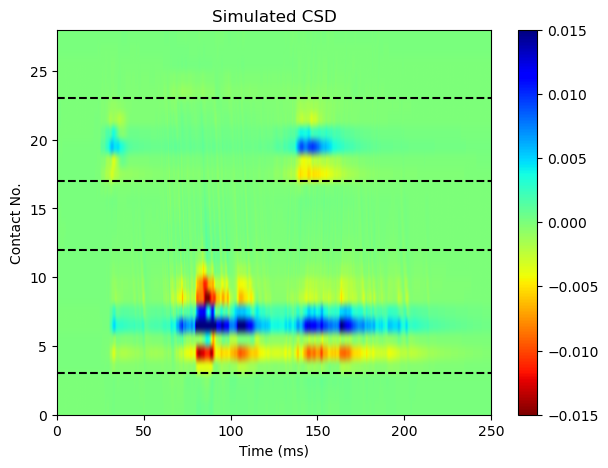

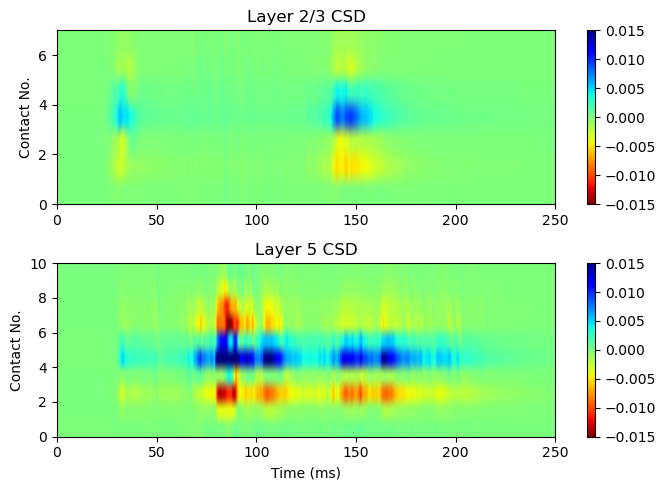

In [8]:
plot_full_csd(csd_data_hnn, times_hnn, layer_boundaries_hnn,
              title='Simulated CSD', vmin=-0.015, vmax=0.015, xmin=0, xmax=250)
plot_csd_layers(l2_data_hnn, l5_data_hnn, times_hnn, xmin=0, xmax=250, vmin=-0.015, vmax=0.015)

### Test shifting cell positions

In [9]:
net_shift = jones_2009_model()
add_erp_drives_to_jones_model(net_shift)

net_shift.add_electrode_array('shank1', electrode_pos)
net_jitter = net_shift.copy()

# Move layer 5 pyr up 500 microns
for idx, pos in enumerate(net_shift.pos_dict['L5_pyramidal']):
    new_pos = (pos[0], pos[1], pos[2] + 500)
    net_shift.pos_dict['L5_pyramidal'][idx] = new_pos

# jitter with standard deviation 100 microns
for idx, pos in enumerate(net_jitter.pos_dict['L5_pyramidal']):
    new_pos = (pos[0], pos[1], pos[2] + (np.random.randn() * 200))
    net_jitter.pos_dict['L5_pyramidal'][idx] = new_pos

dpl_shift = simulate_dipole(net_shift, tstop=tstop, dt=dt, verbose=False)
dpl_jitter = simulate_dipole(net_jitter, tstop=tstop, dt=dt, verbose=False)

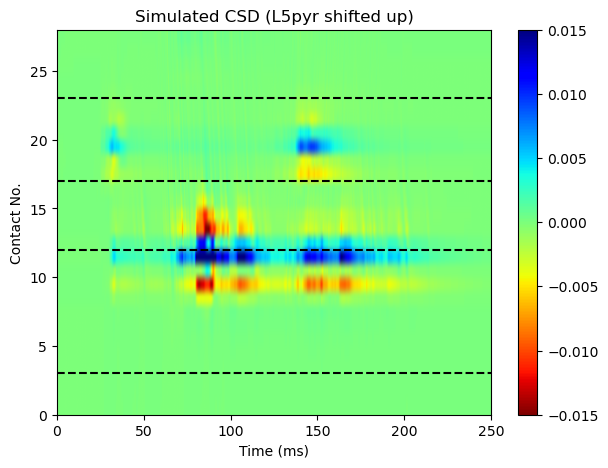

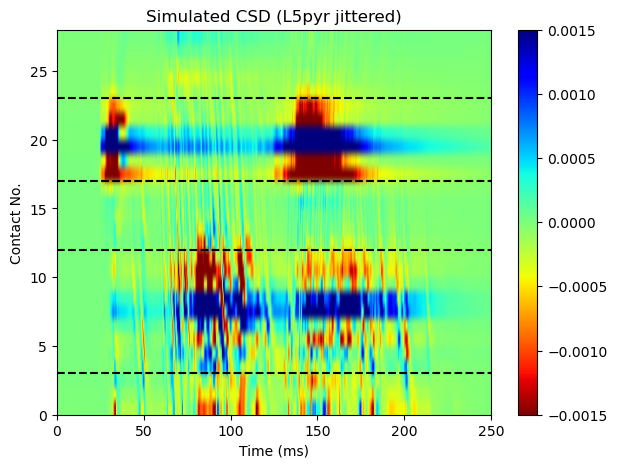

In [10]:
csd_data_hnn_shift = calculate_csd2d(lfp_data=net_shift.rec_arrays['shank1'].voltages[0], delta=delta)
csd_data_hnn_jitter = calculate_csd2d(lfp_data=net_jitter.rec_arrays['shank1'].voltages[0], delta=delta)

plot_full_csd(csd_data_hnn_shift, times_hnn, layer_boundaries_hnn,
              title='Simulated CSD (L5pyr shifted up)', vmin=-0.015, vmax=0.015, xmin=0, xmax=250)

plot_full_csd(csd_data_hnn_jitter, times_hnn, layer_boundaries_hnn,
              title='Simulated CSD (L5pyr jittered)', vmin=-0.0015, vmax=0.0015, xmin=0, xmax=250)


In [51]:
lfp_data = net.rec_arrays['shank1'].voltages[0].copy()
lfp_data = lfp_data[::2,:]

(np.float64(-25.0),
 np.float64(525.0),
 np.float64(-108.11786653878065),
 np.float64(2070.9736015330686))

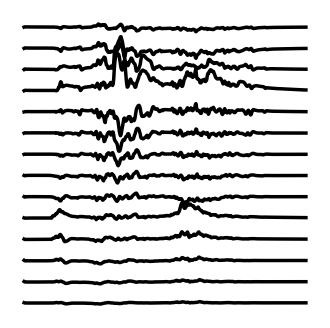

In [53]:
plt.figure(figsize=(4,4))
_ = plt.plot(lfp_data.T + (np.arange(0, lfp_data.shape[0]) * 150), color='k', linewidth=2.5)
plt.axis('off')

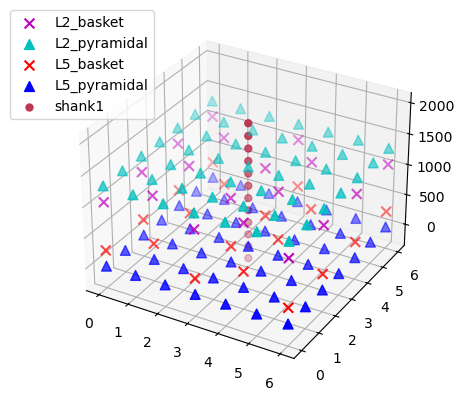

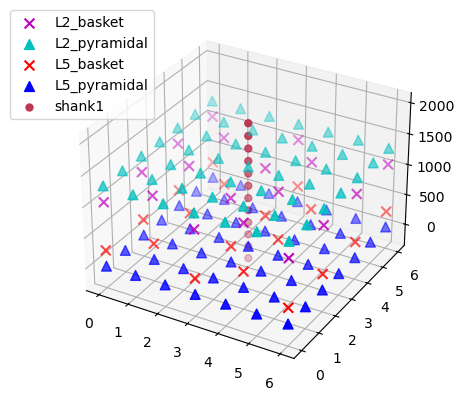

In [42]:
net_plot = jones_2009_model(mesh_shape=(7,7))
depths_plot = np.arange(-200, 2050, 200) # ordering: pial surface -> inward
electrode_pos = [(3, 3, dep) for dep in depths_plot]
net_plot.add_electrode_array('shank1', electrode_pos)
net_plot.plot_cells()
